# 06 — pandas `.plot()` — integración directa con matplotlib

Pandas tiene un wrapper sobre matplotlib que permite hacer gráficos directamente desde un DataFrame sin escribir la lógica de matplotlib manualmente. Para gráficos rápidos de exploración es significativamente más corto.

## Setup

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np
from pathlib import Path

def find_project_root():
    for parent in [Path.cwd()] + list(Path.cwd().parents):
        if (parent / 'data').exists():
            return parent

ROOT  = find_project_root()
TRAIN = ROOT / 'data' / 'external' / 'train.csv'
AIR   = ROOT / 'data' / 'external' / 'Listings.csv'

df = pd.read_csv(TRAIN, low_memory=False)
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
air = pd.read_csv(AIR, encoding='latin-1', low_memory=False)
air_clean = air[(air['price'] > 0) & (air['price'] < 500)].dropna(
    subset=['price', 'accommodates', 'review_scores_rating']
)


## `Series.plot()` — la forma más corta

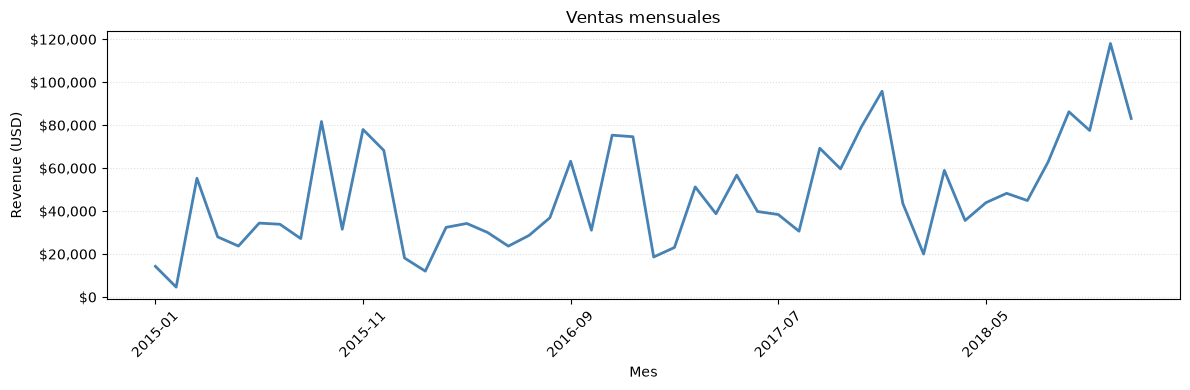

In [2]:
ventas_mes = df.groupby(df['Order Date'].dt.to_period('M').astype(str))['Sales'].sum()

ax = ventas_mes.plot(
    figsize=(12, 4),
    title='Ventas mensuales',
    color='steelblue',
    linewidth=2,
)

ax.set_xlabel('Mes')
ax.set_ylabel('Revenue (USD)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='y', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()


## `DataFrame.plot()` — múltiples líneas automáticamente

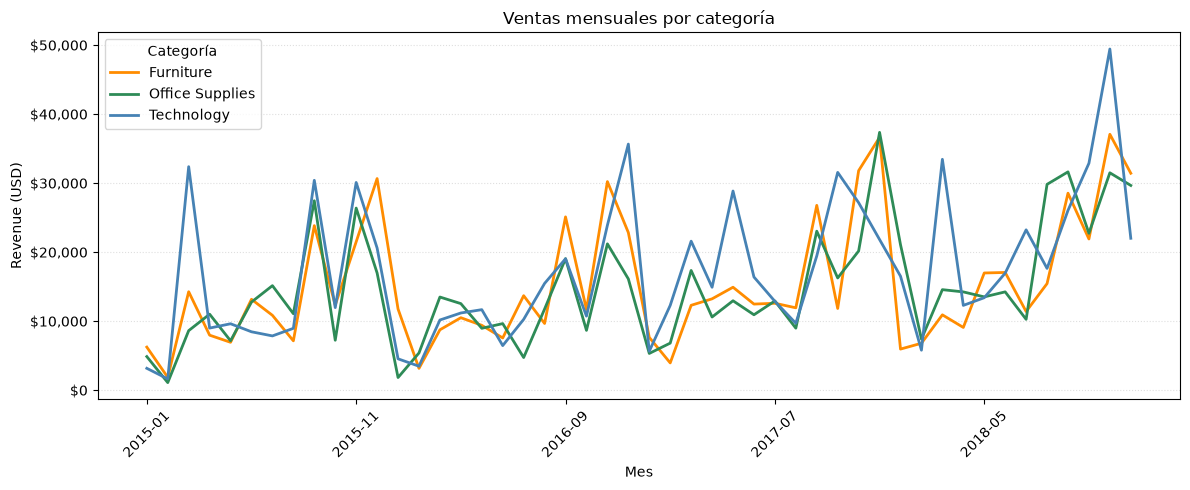

In [3]:
# Cuando el DataFrame tiene varias columnas, plot() las dibuja todas
ventas_cat_mes = (
    df.groupby([df['Order Date'].dt.to_period('M').astype(str), 'Category'])['Sales']
    .sum()
    .unstack('Category')
)

ax = ventas_cat_mes.plot(
    figsize=(12, 5),
    title='Ventas mensuales por categoría',
    linewidth=2,
    color={'Technology': 'steelblue', 'Furniture': 'darkorange',
           'Office Supplies': 'seagreen'},
)

ax.set_xlabel('Mes')
ax.set_ylabel('Revenue (USD)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Categoría')
ax.grid(axis='y', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()


## `kind=` — cambiar el tipo de gráfico

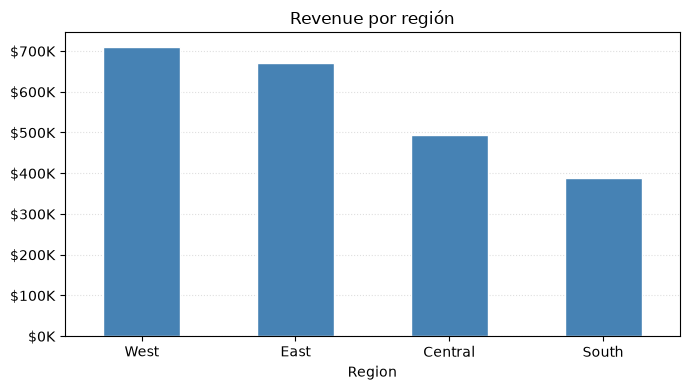

In [4]:
ventas_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

# kind='bar' — barras verticales
ax = ventas_region.plot(
    kind='bar',
    figsize=(7, 4),
    title='Revenue por región',
    color='steelblue',
    edgecolor='white',
)
ax.tick_params(axis='x', rotation=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.grid(axis='y', linestyle=':', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


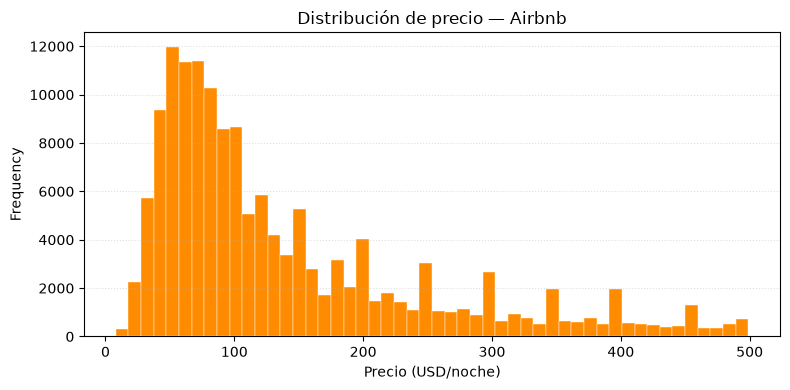

In [5]:
# kind='hist'
ax = air_clean['price'].plot(
    kind='hist',
    bins=50,
    figsize=(8, 4),
    title='Distribución de precio — Airbnb',
    color='darkorange',
    edgecolor='white',
    linewidth=0.3,
)
ax.set_xlabel('Precio (USD/noche)')
ax.grid(axis='y', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()


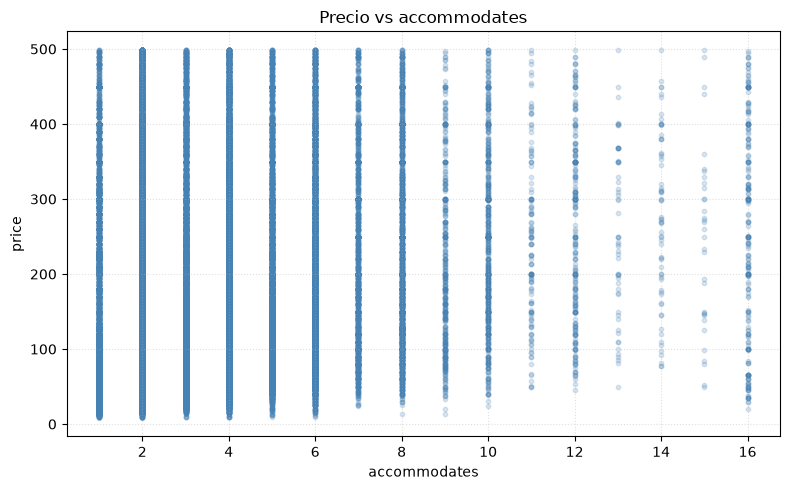

In [6]:
# kind='scatter'
ax = air_clean.plot(
    kind='scatter',
    x='accommodates',
    y='price',
    figsize=(8, 5),
    title='Precio vs accommodates',
    alpha=0.2,
    s=10,
    color='steelblue',
)
ax.grid(linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()


## `ax=` — pasar un Axes existente

La clave de la integración: `df.plot()` acepta un `ax` creado con `plt.subplots()`. Esto permite mezclar pandas plot con matplotlib puro dentro de la misma figura.

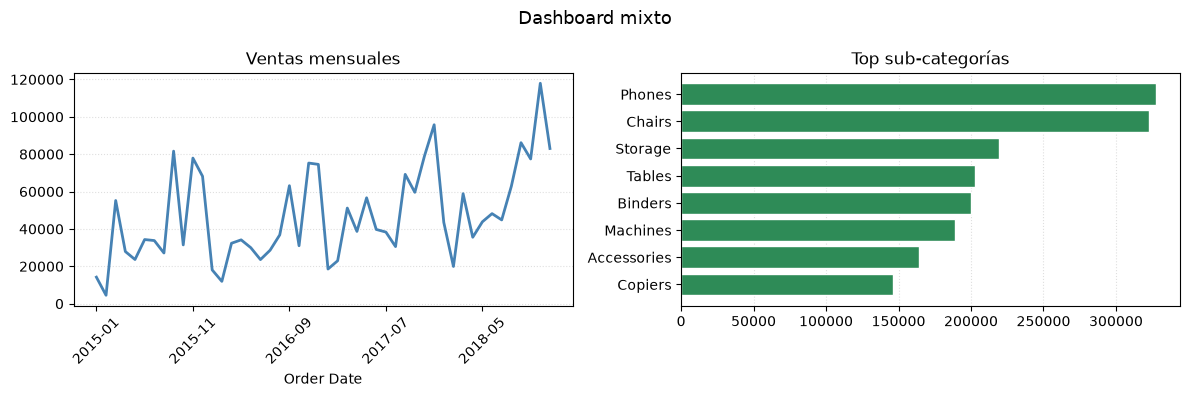

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Primer subplot con pandas plot
ventas_mes = df.groupby(df['Order Date'].dt.to_period('M').astype(str))['Sales'].sum()
ventas_mes.plot(ax=axes[0], color='steelblue', linewidth=2, title='Ventas mensuales')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle=':', alpha=0.4)

# Segundo subplot con matplotlib puro
top_sub = df.groupby('Sub-Category')['Sales'].sum().sort_values().tail(8)
axes[1].barh(top_sub.index, top_sub.values, color='seagreen', edgecolor='white')
axes[1].set_title('Top sub-categorías')
axes[1].grid(axis='x', linestyle=':', alpha=0.4)
axes[1].set_axisbelow(True)

fig.suptitle('Dashboard mixto', fontsize=13)
plt.tight_layout()
plt.show()


---
## Cuándo usar pandas plot vs matplotlib puro

| Situación | Usa |
|-----------|-----|
| Exploración rápida | `df.plot()` — menos código |
| Personalización detallada | matplotlib puro — más control |
| Dashboard con layout complejo | `plt.subplots()` + `ax=` en pandas plot |
| Múltiples columnas en una línea | `df.plot()` — dibuja todas automáticamente |
| Etiquetas de valor en barras | matplotlib puro — pandas no lo hace solo |
